In [1]:
!kaggle datasets download -d rm1000/brain-tumor-mri-scans


Dataset URL: https://www.kaggle.com/datasets/rm1000/brain-tumor-mri-scans
License(s): CC0-1.0
100% 236M/236M [00:14<00:00, 17.3MB/s]



In [2]:
!mkdir -p /content/brain_data
!unzip -q brain-tumor-mri-scans.zip -d /content/brain_data

In [3]:
import numpy as np
from glob import glob

glioma_files = np.array(glob("/content/brain_data/glioma/*"))
meningioma_files = np.array(glob("/content/brain_data/meningioma/*"))
pituitary_files = np.array(glob("/content/brain_data/pituitary/*"))
healthy_files = np.array(glob("/content/brain_data/healthy/*"))

print('There are %d total glioma images.' % len(glioma_files))
print('There are %d total meningioma images.' % len(meningioma_files))
print('There are %d total pituitary images.' % len(pituitary_files))
print('There are %d total healthy images.' % len(healthy_files))

There are 1621 total glioma images.
There are 1645 total meningioma images.
There are 1757 total pituitary images.
There are 2000 total healthy images.


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

## Specify appropriate transforms, and batch_sizes
# define dataloader parameters
batch_size = 32
data_dir = "/content/brain_data"

# Tranformation with data augmentation to be used on the training set
train_transform = transforms.Compose([transforms.RandomRotation(30), # Random rotation with 30 degree
                                       transforms.RandomResizedCrop(224), # Random crop with size of 224*224
                                       transforms.RandomHorizontalFlip(), # Random horizontal flip
                                       transforms.ToTensor(),
                                       transforms.Normalize([0.485, 0.456, 0.406], # Data normalization
                                                            [0.229, 0.224, 0.225])])

# Tranformation with data augmentation to be used on the validation and test set
test_transform = transforms.Compose([transforms.Resize(256), # Resize the image in 255 * 255 before cropping
                                      transforms.CenterCrop(224), # Center crop with size of 224*224
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], # Data normalization
                                                           [0.229, 0.224, 0.225])])


#Load once just to get paths/classes
full_dataset = datasets.ImageFolder(data_dir)

#Split indices
train_size = int(0.70 * len(full_dataset))
valid_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - valid_size

generator = torch.Generator().manual_seed(7)

#apply splits, indices of images
train_subset, valid_subset, test_subset = random_split(
    full_dataset,
    [train_size, valid_size, test_size],
    generator=generator
)

# Reload same dataset with different transforms
train_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(data_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(data_dir, transform=test_transform)

# Defining the datasets for training, validation and testing
train_data = Subset(train_dataset, train_subset.indices)
valid_data = Subset(valid_dataset, valid_subset.indices)
test_data = Subset(test_dataset, test_subset.indices)

# Defining the loaders for training, validation and testing
loaders_scratch = {
    "train": DataLoader(train_data, batch_size=batch_size, shuffle=True),
    "valid": DataLoader(valid_data, batch_size=batch_size, shuffle=False),
    "test": DataLoader(test_data, batch_size=batch_size, shuffle=False)
}


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class BrainCNN(nn.Module):
    ### TODO: choose an architecture, and complete the class
    def __init__(self):
        super(BrainCNN, self).__init__()
        ## Define layers of a CNN
        self.conv1 = nn.Conv2d(3,8,3, padding = 0, stride = 1)
        self.conv2 = nn.Conv2d(8,16,3, padding = 0, stride = 1)
        self.conv3 = nn.Conv2d(16,32,3, padding = 0, stride = 1)
        self.pool = nn.MaxPool2d(2,2, ceil_mode = True)
        self.fc1 = nn.Linear(32 * 27 * 27, 500)
        self.fc2 = nn.Linear(500, 4)


    def forward(self, x):
        ## Define forward behavior
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#-#-# You do NOT have to modify the code below this line. #-#-#

# instantiate the CNN
model_scratch = BrainCNN()

# check if CUDA is available
use_cuda = torch.cuda.is_available()

# move tensors to GPU if CUDA is available
if use_cuda:
    model_scratch.cuda()

In [6]:
import torch.optim as optim
### TODO: select loss function
criterion_scratch = nn.CrossEntropyLoss()

### TODO: select optimizer
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr = 1e-4, weight_decay = 1e-4)

In [7]:
def train(n_epochs, loaders, model, optimizer, criterion, use_cuda, save_path):
    """returns trained model"""
    # initialize tracker for minimum validation loss
    valid_loss_min = np.inf

    for epoch in range(1, n_epochs+1):
        # initialize variables to monitor training and validation loss
        train_loss = 0.0
        valid_loss = 0.0

        ###################
        # train the model #
        ###################
        model.train()
        for batch_idx, (data, target) in enumerate(loaders['train']):
            # move to GPU
            if use_cuda:
                data, target = data.cuda(), target.cuda()
            ## TODO:
            ## find the loss and update the model parameters accordingly
            output = model(data)
            loss = criterion(output, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ## record the average training loss, using something like
            ## train_loss = train_loss + ((1 / (batch_idx + 1)) * (loss.data - train_loss))
            train_loss = train_loss + ((1 / (batch_idx + 1)) * (loss.data - train_loss))

        ######################
        # validate the model #
        ######################
        model.eval()
        for batch_idx, (data, target) in enumerate(loaders['valid']):
            # move to GPU
            if use_cuda:
                data, target = data.cuda(), target.cuda()
            ## TODO:
            ## update the average validation loss
            output = model(data)
            loss = criterion(output, target)
            ## record the average validation loss, using something like
            ## valid_loss = valid_loss + ((1 / (batch_idx + 1)) * (loss.data - valid_loss))
            valid_loss = valid_loss + ((1 / (batch_idx + 1)) * (loss.data - valid_loss))


        # print training/validation statistics
        print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
            epoch,
            train_loss,
            valid_loss
            ))

        ## save the model if validation loss has decreased
        if valid_loss < valid_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, valid_loss))
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss

    # return trained model
    return model


# train the model
n_epochs = 1
model_scratch = train(n_epochs, loaders_scratch, model_scratch, optimizer_scratch, criterion_scratch, use_cuda, 'model_scratch.pt')

# load the model that got the best validation accuracy
model_scratch.load_state_dict(torch.load('model_scratch.pt'))

Epoch: 1 	Training Loss: 1.093688 	Validation Loss: 0.836412
Validation loss decreased (inf --> 0.836412).  Saving model ...


<All keys matched successfully>

In [8]:
def test(loaders, model, criterion, use_cuda):

    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval()
    for batch_idx, (data, target) in enumerate(loaders['test']):
        # move to GPU
        if use_cuda:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # update average test loss
        test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data - test_loss))
        # convert output probabilities to predicted class
        pred = output.data.max(1, keepdim=True)[1]
        # compare predictions to true label
        correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
        total += data.size(0)

    print('Test Loss: {:.6f}\n'.format(test_loss))

    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total))

# call test function
test(loaders_scratch, model_scratch, criterion_scratch, use_cuda)

Test Loss: 0.780054


Test Accuracy: 73% (772/1054)


In [9]:
print(len(train_data), len(valid_data), len(test_data))
print(len(set(train_subset.indices) & set(valid_subset.indices)))
print(len(set(train_subset.indices) & set(test_subset.indices)))
print(len(set(valid_subset.indices) & set(test_subset.indices)))

4916 1053 1054
0
0
0


In [10]:
print(model_scratch)

BrainCNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (fc1): Linear(in_features=23328, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=4, bias=True)
)


In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_targets = []

model_scratch.eval()

with torch.no_grad():
    for data, target in loaders_scratch['test']:
        if use_cuda:
            data, target = data.cuda(), target.cuda()

        output = model_scratch(data)
        preds = output.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

print(cm)

[[194   0  42  30]
 [ 13 239  24  27]
 [ 54  24  97  44]
 [  8   6  10 242]]


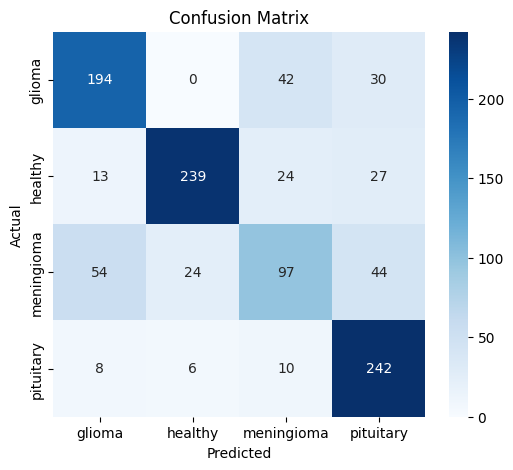

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# class names
class_names = ['glioma', 'healthy', 'meningioma', 'pituitary']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import torch

# Put model in evaluation mode
model_scratch.eval()

# Lists to store predictions and true labels
y_true = []
y_pred = []

# Disable gradient calculations
with torch.no_grad():
    for data, target in loaders_scratch['test']:

        # Move tensors to GPU if available
        if use_cuda:
            data = data.cuda()
            target = target.cuda()

        # Forward pass
        output = model_scratch(data)

        # Get predicted class
        _, preds = torch.max(output, 1)

        # Store predictions and labels
        y_true.extend(target.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Calculate metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print overall metrics
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Print full classification report
class_names = ['Glioma', 'Healthy', 'Meningioma', 'Pituitary']

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Precision: 0.7320
Recall:    0.7324
F1-Score:  0.7267

Classification Report:

              precision    recall  f1-score   support

      Glioma       0.72      0.73      0.73       266
     Healthy       0.89      0.79      0.84       303
  Meningioma       0.56      0.44      0.49       219
   Pituitary       0.71      0.91      0.79       266

    accuracy                           0.73      1054
   macro avg       0.72      0.72      0.71      1054
weighted avg       0.73      0.73      0.73      1054



In [14]:
## Specify data loaders (we use the same data loader created in scratch)
loaders_transfer = loaders_scratch.copy()

In [15]:
import torchvision.models as models
import torch.nn as nn
from collections import OrderedDict

##Specify model architecture
## name the model as `model_transfer`
#Decided to go with densenet 121 since it is smaller model than densenet161 due to the baseline accuracy of our model from scratch
model_transfer = models.densenet121(pretrained=True)

# Freeze training for all "features" layers
for param in model_transfer.parameters():
    param.requires_grad = False

# replace the last fully connected layer with a Linear layer 4 output
n_input = model_transfer.classifier.in_features # save to checkpoints
n_output = 4
model_transfer.classifier = nn.Sequential(OrderedDict([
                          ('0', nn.Linear(n_input, 256)),
                          ('1', nn.ReLU()),
                          ('2', nn.Dropout(0.25)),
                          ('3', nn.Linear(256, n_output)),
                          ('4', nn.LogSoftmax(dim=1))
                          ]))
if use_cuda:
    model_transfer = model_transfer.cuda()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:00<00:00, 217MB/s]


In [16]:
print(model_transfer)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [17]:
criterion_transfer = nn.NLLLoss()
optimizer_transfer = optim.Adam(model_transfer.classifier.parameters(), lr = 1e-3, weight_decay = 1e-4)

In [18]:
# train the model
n_epochs = 10
#model_transfer = train(n_epochs, loaders_transfer, model_transfer, optimizer_transfer, criterion_transfer, use_cuda, 'model_transfer.pt')

# load the model that got the best validation accuracy
#model_transfer.load_state_dict(torch.load('model_transfer.pt'))

FileNotFoundError: [Errno 2] No such file or directory: 'model_transfer.pt'

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import torchvision.models as models
import torch.nn as nn
from collections import OrderedDict
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_transfer = models.densenet121(pretrained=True)

for param in model_transfer.parameters():
    param.requires_grad = False

n_input = model_transfer.classifier.in_features
n_output = 4

model_transfer.classifier = nn.Sequential(OrderedDict([
    ('0', nn.Linear(n_input, 256)),
    ('1', nn.ReLU()),
    ('2', nn.Dropout(0.25)),
    ('3', nn.Linear(256, n_output)),
    ('4', nn.LogSoftmax(dim=1))
]))

path = "/content/drive/MyDrive/model_transfer.pt"

model_transfer.load_state_dict(
    torch.load(path, map_location=device)
)

model_transfer.to(device)
model_transfer.eval()

Mounted at /content/drive


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [20]:
test(loaders_transfer, model_transfer, criterion_transfer, use_cuda)

Test Loss: 0.279835


Test Accuracy: 88% (936/1054)


In [21]:
all_preds = []
all_targets = []

model_transfer.eval()

with torch.no_grad():
    for data, target in loaders_transfer['test']:
        if use_cuda:
            data, target = data.cuda(), target.cuda()

        output = model_transfer(data)
        preds = output.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

print(cm)

[[232   1  32   1]
 [  3 292   4   4]
 [ 22  12 173  12]
 [  6   0  21 239]]


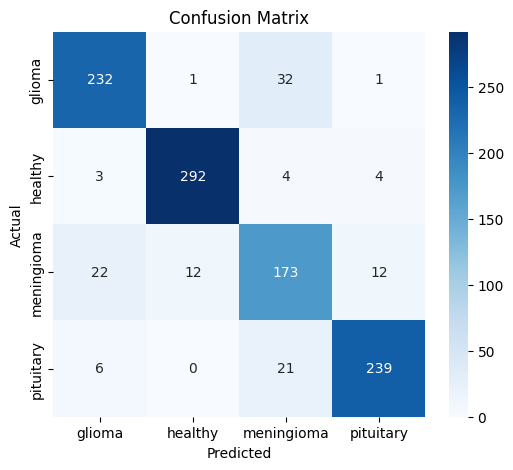

In [22]:
# class names
class_names = ['glioma', 'healthy', 'meningioma', 'pituitary']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import torch

# Put model in evaluation mode
model_transfer.eval()

# Lists to store predictions and true labels
y_true = []
y_pred = []

# Disable gradient calculations
with torch.no_grad():
    for data, target in loaders_scratch['test']:

        # Move tensors to GPU if available
        if use_cuda:
            data = data.cuda()
            target = target.cuda()

        # Forward pass
        output = model_transfer(data)

        # Get predicted class
        _, preds = torch.max(output, 1)

        # Store predictions and labels
        y_true.extend(target.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Calculate metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print overall metrics
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Print full classification report
class_names = ['Glioma', 'Healthy', 'Meningioma', 'Pituitary']

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Precision: 0.8897
Recall:    0.8880
F1-Score:  0.8887

Classification Report:

              precision    recall  f1-score   support

      Glioma       0.88      0.87      0.88       266
     Healthy       0.96      0.96      0.96       303
  Meningioma       0.75      0.79      0.77       219
   Pituitary       0.93      0.90      0.92       266

    accuracy                           0.89      1054
   macro avg       0.88      0.88      0.88      1054
weighted avg       0.89      0.89      0.89      1054



In [25]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 107.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=06f37a1314c4e214398e045efcab262f9a4f034b3abdc753b4f560e00106aec9
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


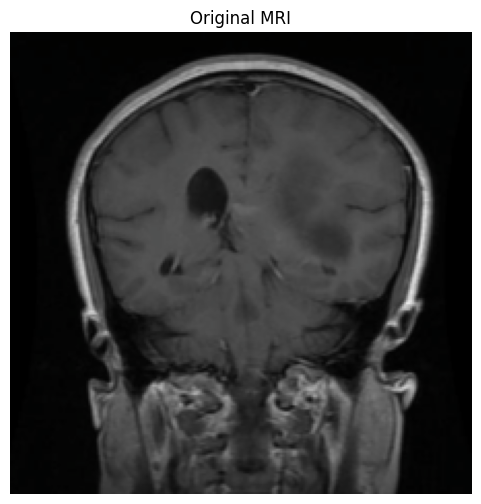

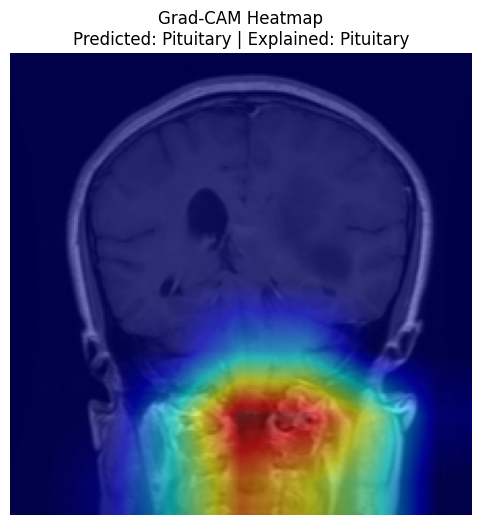

Predicted class: 3
Explained class: 3


In [37]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_transfer.to(device)
model_transfer.eval()

for param in model_transfer.parameters():
    param.requires_grad = True

def gradcam_heatmap(model, image_tensor, label=None, class_names=None):
    model.eval()

    # image_tensor shape: [3, 224, 224]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # Get prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Explain true label if given, otherwise predicted class
    target_class = label if label is not None else pred_class
    targets = [ClassifierOutputTarget(target_class)]

    # Better DenseNet-121 target layer
    target_layers = [model.features.denseblock4]

    # Convert image for display
    img = image_tensor.detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1).astype(np.float32)

    # Grad-CAM
    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    visualization = show_cam_on_image(
        img,
        grayscale_cam,
        use_rgb=True
    )

    if class_names is not None:
        title = f"Predicted: {class_names[pred_class]} | Explained: {class_names[target_class]}"
    else:
        title = f"Predicted: {pred_class} | Explained: {target_class}"

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Original MRI")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title("Grad-CAM Heatmap\n" + title)
    plt.axis("off")
    plt.show()

    print("Predicted class:", pred_class)
    print("Explained class:", target_class)

images, labels = next(iter(loaders_transfer['test']))

image = images[6]
label = labels[6].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

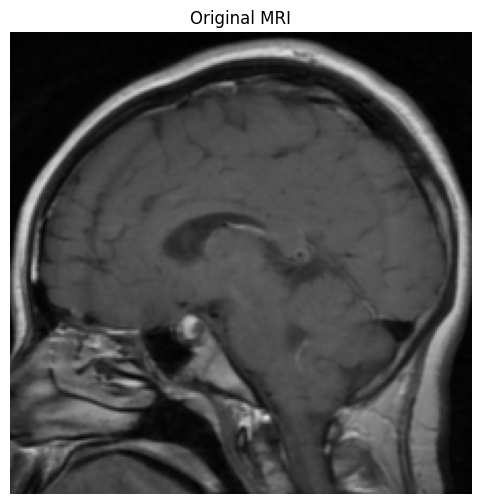

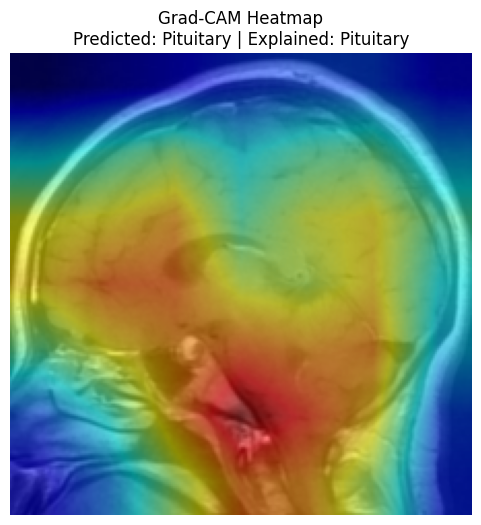

Predicted class: 3
Explained class: 3


In [35]:

image = images[9]
label = labels[9].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

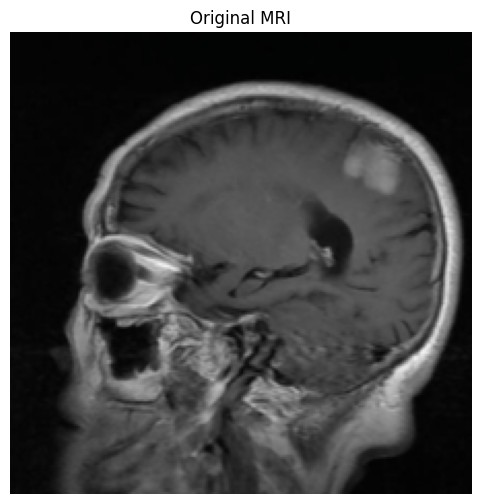

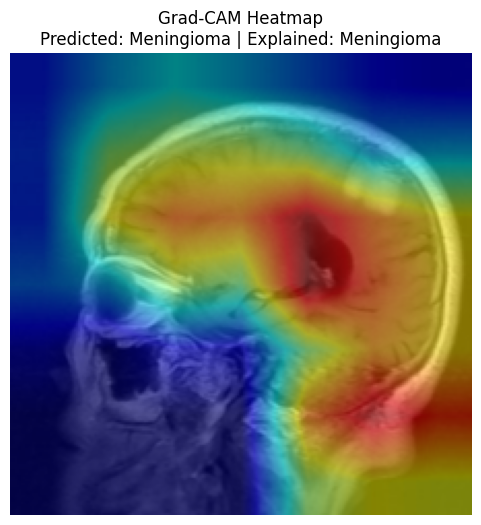

Predicted class: 2
Explained class: 2


In [28]:

image = images[10]
label = labels[10].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

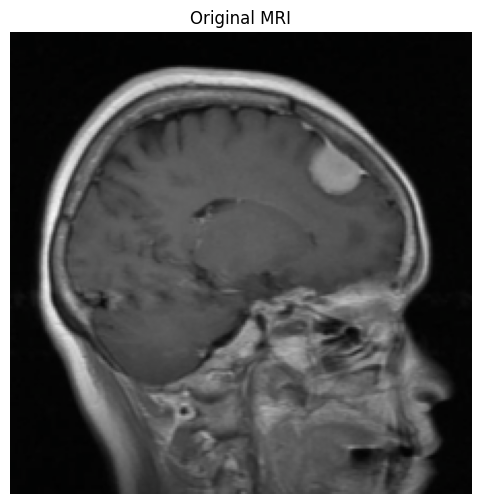

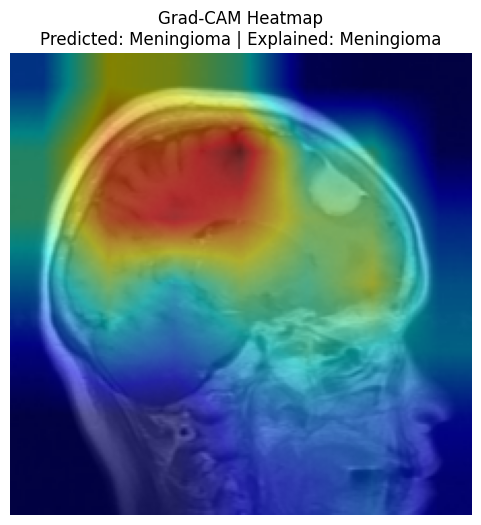

Predicted class: 2
Explained class: 2


In [29]:

image = images[15]
label = labels[15].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

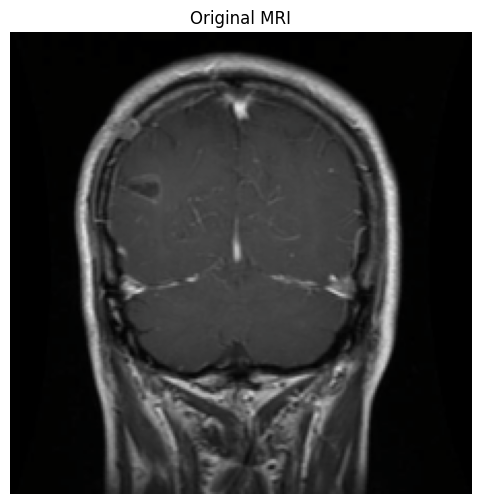

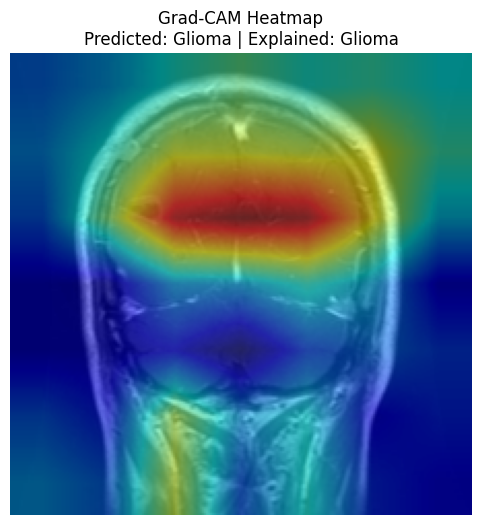

Predicted class: 0
Explained class: 0


In [30]:

image = images[16]
label = labels[16].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

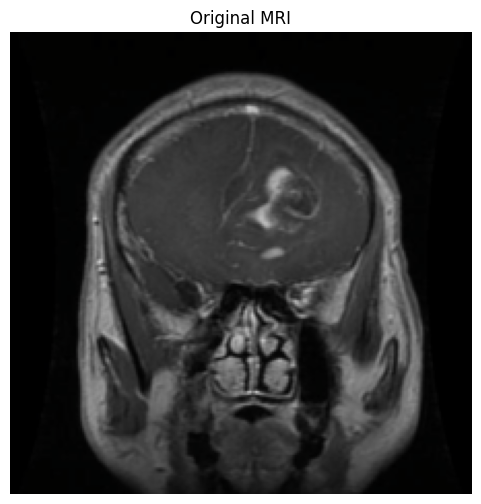

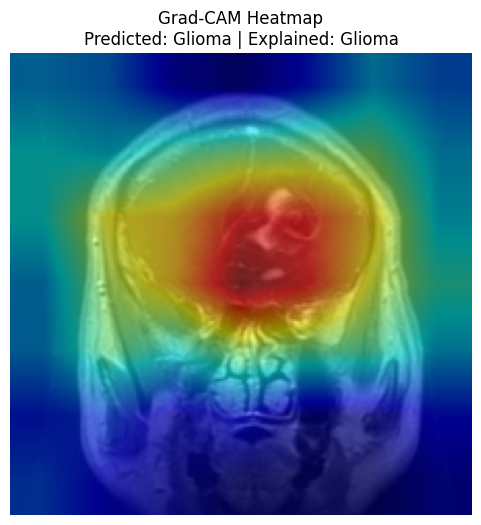

Predicted class: 0
Explained class: 0


In [32]:

image = images[18]
label = labels[18].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

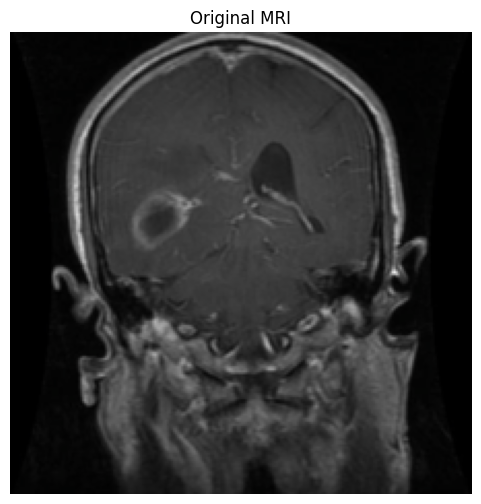

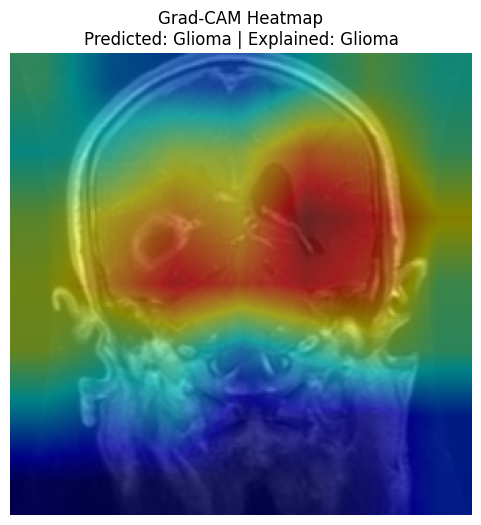

Predicted class: 0
Explained class: 0


In [33]:

image = images[19]
label = labels[19].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

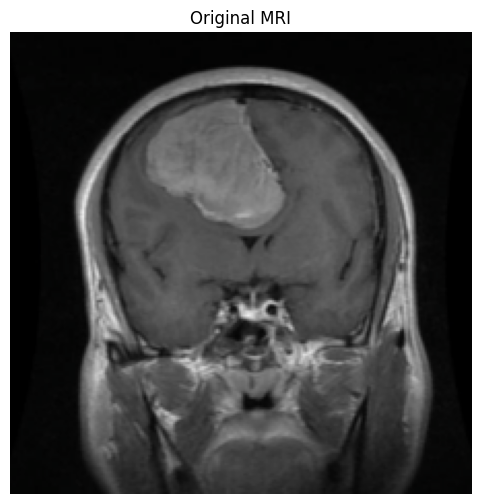

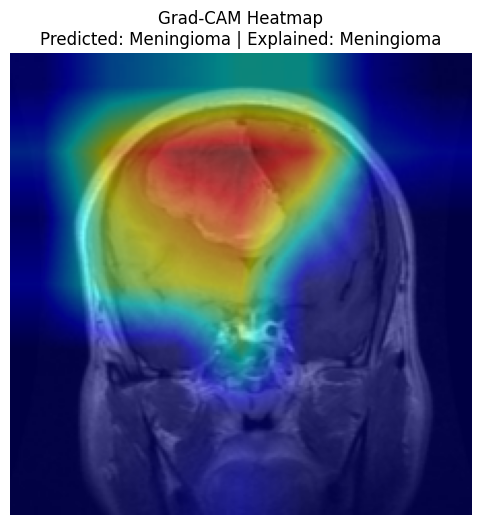

Predicted class: 2
Explained class: 2


In [42]:

image = images[24]
label = labels[24].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

In [51]:

image = images[33]
label = labels[33].item()

gradcam_heatmap(
    model_transfer,
    image,
    label=None,
    class_names=class_names
)

IndexError: index 33 is out of bounds for dimension 0 with size 32